<a href="https://colab.research.google.com/github/SPARSHTHALYARI/SPARSHTHALYARI/blob/main/Hate_Speech_Detection(using_DNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
# import the required libraries
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [46]:
tweet_df = pd.read_csv('train.csv')

In [33]:
tweet_df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [34]:
tweet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [35]:

#printing first 5 id Data on twitter
tweet_df.iloc[0]
tweet_df.iloc[0:5]

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [36]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Ensure you have the necessary NLTK data downloaded
import nltk
nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def data_processing(tweet):
    # Convert to lowercase
    tweet = tweet.lower()

    # Remove URLs
    tweet = re.sub(r"https\S+|www\S+", '', tweet)

    # Remove mentions and hashtags
    tweet = re.sub(r'@\w+|#\w+', '', tweet)

    # Remove punctuation
    tweet = re.sub(r'[^\w\s]', '', tweet)

    # Remove special character 'ð'
    tweet = tweet.replace('ð', '')

    # Tokenize the tweet
    tweet_tokens = word_tokenize(tweet)

    # Remove stop words
    filtered_tweets = [w for w in tweet_tokens if not w in stop_words]

    return " ".join(filtered_tweets)



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [37]:
tweet_df.tweet = tweet_df['tweet'].apply(data_processing)

In [38]:

tweet_df = tweet_df.drop_duplicates('tweet')

In [39]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatizing(data):
    lemmatized_tweet = [lemmatizer.lemmatize(word) for word in data]
    return lemmatized_tweet


In [40]:
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('stopwords')



tweet_df['tweet'] = tweet_df['tweet'].apply(lambda x: lemmatizing(x))


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [41]:
# printing the data to see the effect of preprocessing
print(tweet_df['tweet'].iloc[0],"\n")
print(tweet_df['tweet'].iloc[1],"\n")
print(tweet_df['tweet'].iloc[2],"\n")
print(tweet_df['tweet'].iloc[3],"\n")
print(tweet_df['tweet'].iloc[4],"\n")



['f', 'a', 't', 'h', 'e', 'r', ' ', 'd', 'y', 's', 'f', 'u', 'n', 'c', 't', 'i', 'o', 'n', 'a', 'l', ' ', 's', 'e', 'l', 'f', 'i', 's', 'h', ' ', 'd', 'r', 'a', 'g', 's', ' ', 'k', 'i', 'd', 's', ' ', 'd', 'y', 's', 'f', 'u', 'n', 'c', 't', 'i', 'o', 'n'] 

['t', 'h', 'a', 'n', 'k', 's', ' ', 'c', 'r', 'e', 'd', 'i', 't', ' ', 'c', 'a', 'n', 't', ' ', 'u', 's', 'e', ' ', 'c', 'a', 'u', 's', 'e', ' ', 'd', 'o', 'n', 't', ' ', 'o', 'f', 'f', 'e', 'r', ' ', 'w', 'h', 'e', 'e', 'l', 'c', 'h', 'a', 'i', 'r', ' ', 'v', 'a', 'n', 's', ' ', 'p', 'd', 'x'] 

['b', 'i', 'h', 'd', 'a', 'y', ' ', 'm', 'a', 'j', 'e', 's', 't', 'y'] 

['l', 'o', 'v', 'e', ' ', 'u', ' ', 't', 'a', 'k', 'e', ' ', 'u', ' ', 't', 'i', 'm', 'e', ' ', 'u', 'r'] 

['f', 'a', 'c', 't', 's', 'g', 'u', 'i', 'd', 'e', ' ', 's', 'o', 'c', 'i', 'e', 't', 'y'] 



In [42]:
tweet_df.info()
tweet_df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
Index: 26806 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      26806 non-null  int64 
 1   label   26806 non-null  int64 
 2   tweet   26806 non-null  object
dtypes: int64(2), object(1)
memory usage: 837.7+ KB


,count
label,
0,25013
1,1793


Now We will Visualize Our Dataset using count plot and pie chart plot

<Axes: xlabel='label', ylabel='count'>

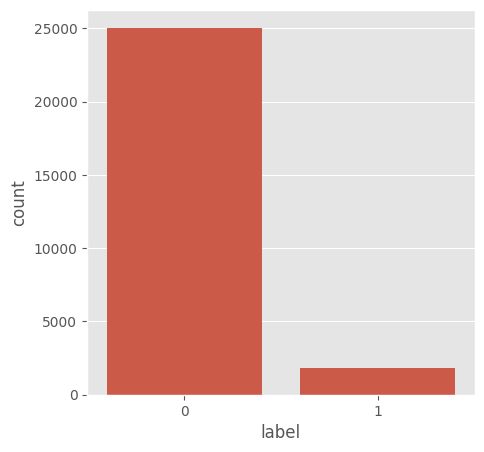

In [43]:

#here is the count Plot
fig = plt.figure(figsize=(5,5))
sns.countplot(x='label', data = tweet_df)


Text(0.5, 1.0, 'Distribution of sentiments')

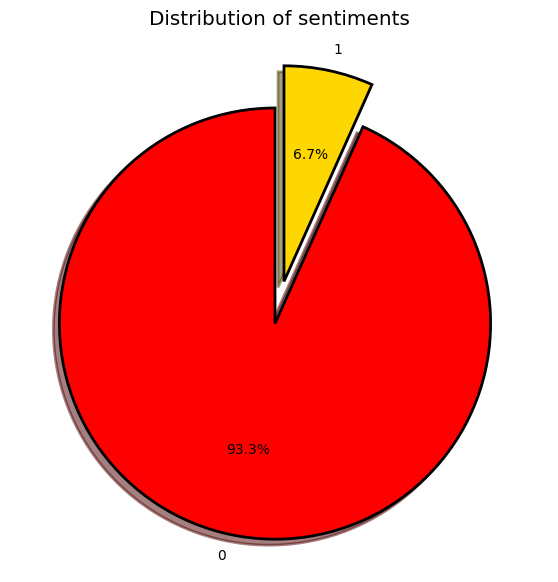

In [44]:
# here is Our Pie Plot

fig = plt.figure(figsize=(7,7))
colors = ("red", "gold")
wp = {'linewidth':2, 'edgecolor':"black"}
tags = tweet_df['label'].value_counts()
explode = (0.1, 0.1)
tags.plot(kind='pie',autopct = '%1.1f%%', shadow=True, colors = colors, startangle =90,
         wedgeprops = wp, explode = explode, label='')
plt.title('Distribution of sentiments')




In [47]:
non_hate_tweets = tweet_df[tweet_df.label == 0]
non_hate_tweets.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


<ipython-input-48-9148ebfb3585>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_hate_tweets['tweet'] = non_hate_tweets['tweet'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)


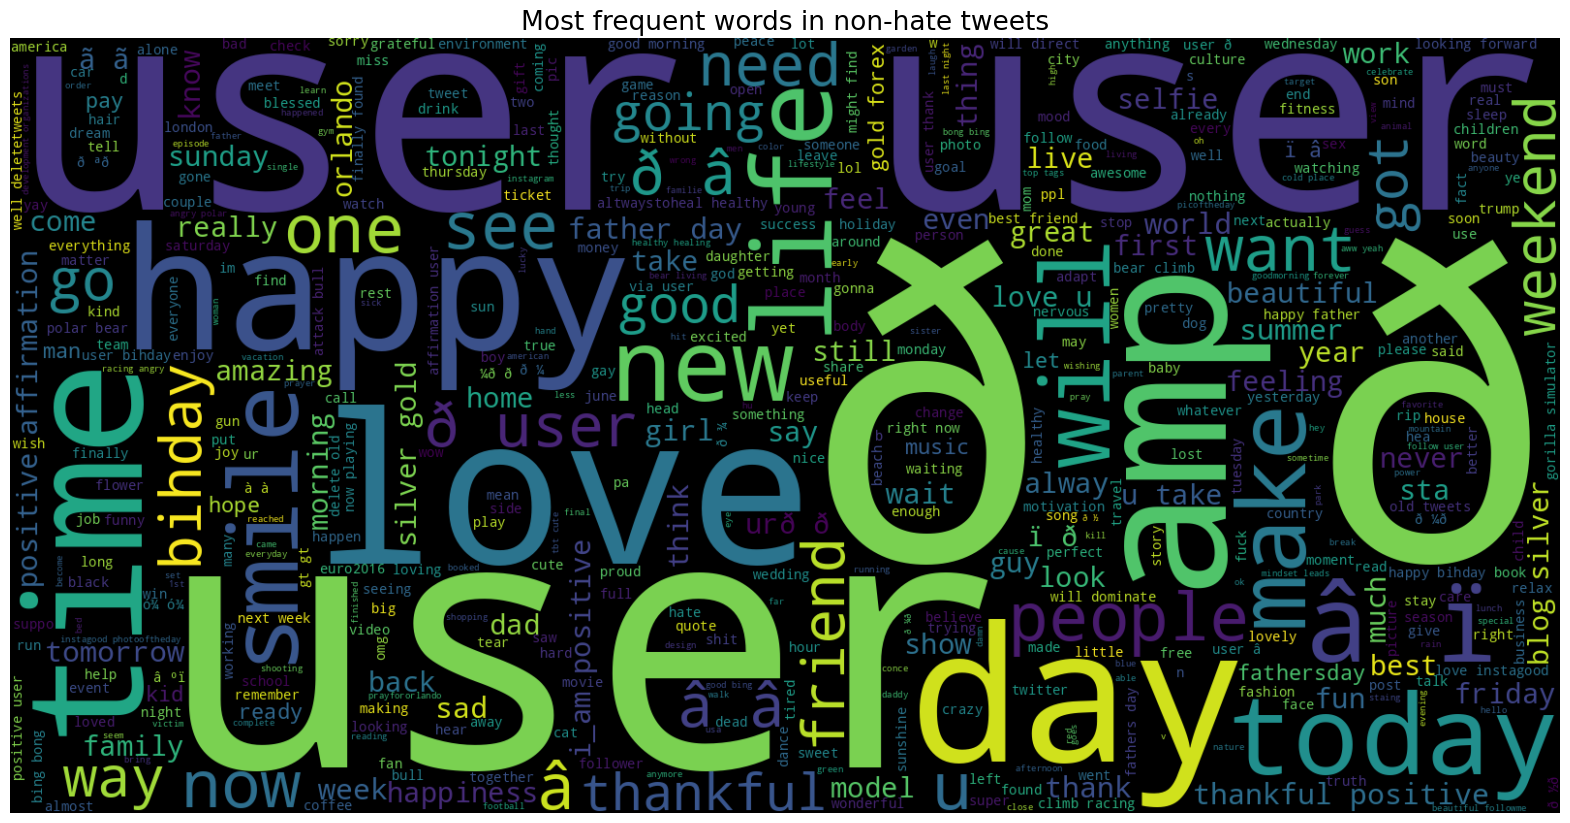

In [48]:
# Ensure each tweet is a string
non_hate_tweets['tweet'] = non_hate_tweets['tweet'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)

# Combine all non-hate tweets into a single string
text = ' '.join(non_hate_tweets['tweet'].tolist())

# Create a word cloud figure
plt.figure(figsize=(20, 15), facecolor='None')

# Generate the word cloud
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)

# Display the word cloud image
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off axis
plt.title('Most frequent words in non-hate tweets', fontsize=19)
plt.show()


In [49]:

neg_tweets = tweet_df[tweet_df.label == 1]
neg_tweets.head()



,id,label,tweet
13,14,1,@user #cnn calls #michigan middle school 'buil...
14,15,1,no comment! in #australia #opkillingbay #se...
17,18,1,retweet if you agree!
23,24,1,@user @user lumpy says i am a . prove it lumpy.
34,35,1,it's unbelievable that in the 21st century we'...


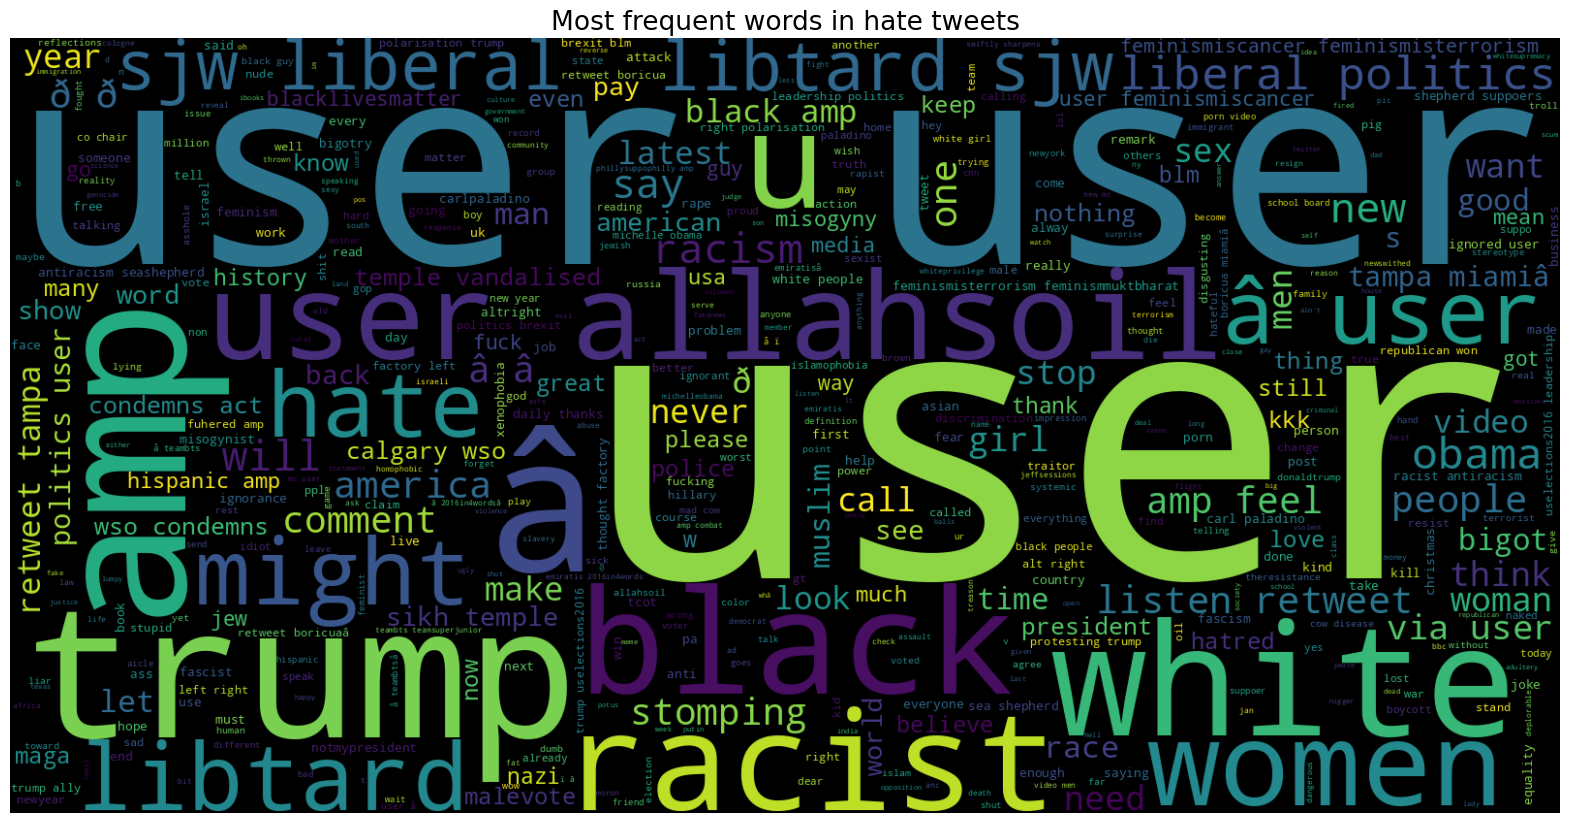

In [50]:
text = ' '.join([word for word in neg_tweets['tweet']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words in hate tweets', fontsize = 19)
plt.show()


In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize and fit the TfidfVectorizer
vect = TfidfVectorizer(ngram_range=(1,2)).fit(tweet_df['tweet'])

# Retrieve the feature names
feature_names = vect.get_feature_names_out()

# Print the number of features
print("Number of features: {}\n".format(len(feature_names)))

# Print the first 20 features
print("First 20 features: \n{}".format(feature_names[:20]))


Number of features: 228267

First 20 features: 
['00' '00 35' '00 and' '00 blog' '00 drops' '00 folkmusic' '00 from'
 '00 get' '00 hours' '00 level' '00 mark' '00 on' '00 online' '00 open'
 '00 psychological' '00 shopalyssas' '00 suppo' '00 upsideofflorida'
 '00 warnung' '00 what']


In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize and fit the TfidfVectorizer
vect = TfidfVectorizer(ngram_range=(1,2)).fit(tweet_df['tweet'])

# Retrieve the feature names
feature_names = vect.get_feature_names_out()

# Print the number of features
print("Number of features: {}\n".format(len(feature_names)))

# Print the first 20 features
print("First 20 features: \n{}".format(feature_names[:20]))


Number of features: 228267

First 20 features: 
['00' '00 35' '00 and' '00 blog' '00 drops' '00 folkmusic' '00 from'
 '00 get' '00 hours' '00 level' '00 mark' '00 on' '00 online' '00 open'
 '00 psychological' '00 shopalyssas' '00 suppo' '00 upsideofflorida'
 '00 warnung' '00 what']


In [57]:

X = tweet_df['tweet']
Y = tweet_df['label']
X = vect.transform(X)

In [59]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [60]:
print("Size of x_train:", (x_train.shape))
print("Size of y_train:", (y_train.shape))
print("Size of x_test: ", (x_test.shape))
print("Size of y_test: ", (y_test.shape))


Size of x_train: (25569, 228267)
Size of y_train: (25569,)
Size of x_test:  (6393, 228267)
Size of y_test:  (6393,)


In [61]:
logreg = LogisticRegression()
logreg.fit(x_train, y_train)
logreg_predict = logreg.predict(x_test)
logreg_acc = accuracy_score(logreg_predict, y_test)
print("Test accuarcy: {:.2f}%".format(logreg_acc*100))


Test accuarcy: 93.96%


In [62]:
print(confusion_matrix(y_test, logreg_predict))
print("\n")
print(classification_report(y_test, logreg_predict))



[[5937    0]
 [ 386   70]]


              precision    recall  f1-score   support

           0       0.94      1.00      0.97      5937
           1       1.00      0.15      0.27       456

    accuracy                           0.94      6393
   macro avg       0.97      0.58      0.62      6393
weighted avg       0.94      0.94      0.92      6393



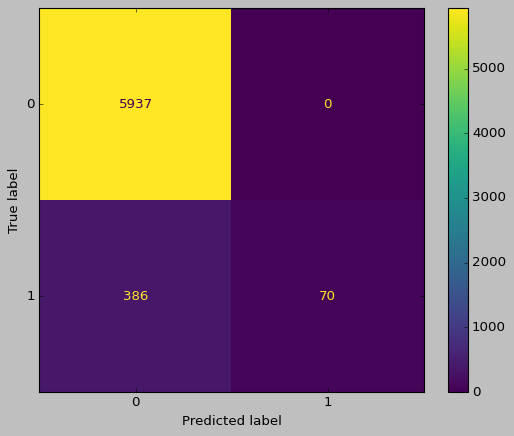

In [63]:
style.use('classic')
cm = confusion_matrix(y_test, logreg_predict, labels=logreg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg.classes_)
disp.plot()




In [64]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [65]:
param_grid = {'C':[100, 10, 1.0, 0.1, 0.01], 'solver' :['newton-cg', 'lbfgs','liblinear']}
grid = GridSearchCV(LogisticRegression(), param_grid, cv = 5)
grid.fit(x_train, y_train)
print("Best Cross validation score: {:.2f}".format(grid.best_score_))
print("Best parameters: ", grid.best_params_)



Best Cross validation score: 0.96
Best parameters:  {'C': 100, 'solver': 'newton-cg'}


In [66]:
y_pred = grid.predict(x_test)

In [67]:
logreg_acc = accuracy_score(y_pred, y_test)
print("Test accuracy: {:.2f}%".format(logreg_acc*100))


Test accuracy: 95.93%


In [68]:
#Hyperparameter Tuning: Uses GridSearchCV to find the best hyperparameters for a LogisticRegression model.
#Parameter Grid: Searches over different values of the regularization parameter C and solver algorithms.
#Cross-Validation: Evaluates each parameter combination using 5-fold cross-validation.
#Results: Prints the best cross-validation score and the corresponding hyperparameters.

print(confusion_matrix(y_test, y_pred))
print("\n")
print(classification_report(y_test, y_pred))

[[5926   11]
 [ 249  207]]


              precision    recall  f1-score   support

           0       0.96      1.00      0.98      5937
           1       0.95      0.45      0.61       456

    accuracy                           0.96      6393
   macro avg       0.95      0.73      0.80      6393
weighted avg       0.96      0.96      0.95      6393

